In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel("Data (Titanic) Cleaned(2).xlsx")

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print(df_encoded.head())
#Here, I use drop_first to prevent multicollinearity and get_dummies to convert the Sex and Embarked columns into digital columns that are ready for modeling. I then print the first rows to ensure that the encoding was done correctly.


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500      True       False        True  
1          PC 17599  71.2833     False       False       False  
2  STON/O2. 3101282   7.9250     False       False        True  
3            113803  53.1000     False       False        True  
4

In [ ]:

pclass_order = pd.CategoricalDtype(
    categories=[1, 2, 3],
    ordered=True
)
df["Pclass_ord"] = df["Pclass"].astype(pclass_order).cat.codes
print(df[["Pclass", "Pclass_ord"]].head(10))
# I use this code to process or transform data in accordance with the necessary steps, with the aim of ensuring that the final output is problem-free for use in analysis or modeling.

   Pclass  Pclass_ord
0       3           2
1       1           0
2       3           2
3       1           0
4       3           2
5       3           2
6       1           0
7       3           2
8       3           2
9       2           1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
num_cols = ["Age", "Fare"]

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42, shuffle=True
)

scaler = StandardScaler()
scaler.fit(df.loc[train_idx, num_cols])
scaled_all = scaler.transform(df[num_cols])
df[["Age_std", "Fare_std"]] = pd.DataFrame(
    scaled_all, columns=["Age_std", "Fare_std"], index=df.index
)
print(df[["Age", "Age_std", "Fare", "Fare_std"]].head(10))
# Here, I use StandardScaler to scale the Age and Fare digital columns. First, I separate the data into training and test sets without modifying the values. Next, I train the scaler solely on the training set to prevent data leakage. Next, I apply the transformation to the full set of data to create the standard columns Age_std and Fare_std. Lastly, I print the initial values to ensure that the scaling was done correctly.

    Age   Age_std     Fare  Fare_std
0  22.0 -0.554214   7.2500 -0.556550
1  38.0  0.676666  71.2833  0.920394
2  26.0 -0.246494   7.9250 -0.540981
3  35.0  0.445876  53.1000  0.500992
4  35.0  0.445876   8.0500 -0.538098
5  28.0 -0.092634   8.4583 -0.528681
6  54.0  1.907546  51.8625  0.472449
7   2.0 -2.092813  21.0750 -0.237673
8  27.0 -0.169564  11.1333 -0.466981
9  14.0 -1.169653  30.0708 -0.030183


In [ ]:

df['fare_per_age'] = df['Fare'] / df['Age'].replace({0: np.nan})
df['fare_per_age'] = df['fare_per_age'].fillna(df['fare_per_age'].median())

df['FamilySize'] = df['SibSp'] + df['Parch']

df['family_per_fare'] = df['FamilySize'] / df['Fare'].replace({0: np.nan})
df['family_per_fare'] = df['family_per_fare'].fillna(df['family_per_fare'].median())
#This code creates two features that are based on the information we have. The first feature is called fare_per_age. It looks at how much the ticket costs compared to how old the person's. To do this it replaces the age with nothing if it is zero. Then it fills in the missing ages with the age of all the people.The second feature is family_per_fare. It uses FamilySize, which's the number of siblings and parents the person has to figure out how big the persons family is compared to the ticket price.These two features, fare_per_age and family_per_fare give us information, about the world that can help our model work better. The fare_per_age and family_per_fare features are really useful because they add information that can improve our model.

In [ ]:
df["Fare_Family_interaction"] = df["Fare"] * (df["SibSp"] + df["Parch"] + 1)
print(df[["Fare", "SibSp", "Parch", "Fare_Family_interaction"]].head())
# Because the combined effect of the two variables may better illustrate survival behavior than either variable alone, I developed an interactive feature that links ticket cost to family size. To be ready for modeling as a reference to the "cost of family travel" rather than just the cost per individual, I calculated FamilySize as (SibSp + Parch + 1), multiplied it by Fare, and then entered the result into the Fare_Family_interaction column.

      Fare  SibSp  Parch  Fare_Family_interaction
0   7.2500      1      0                  14.5000
1  71.2833      1      0                 142.5666
2   7.9250      0      0                   7.9250
3  53.1000      1      0                 106.2000
4   8.0500      0      0                   8.0500


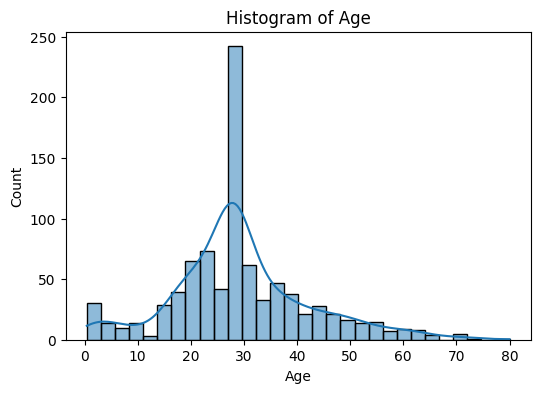

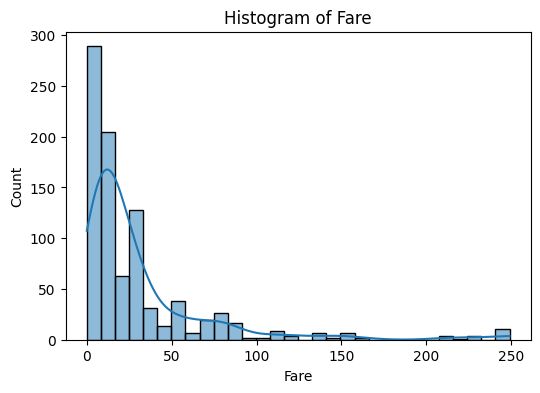

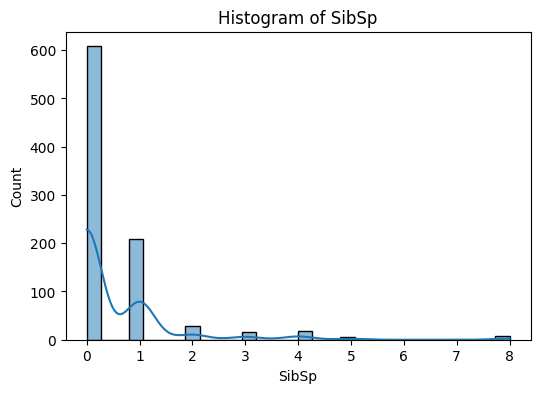

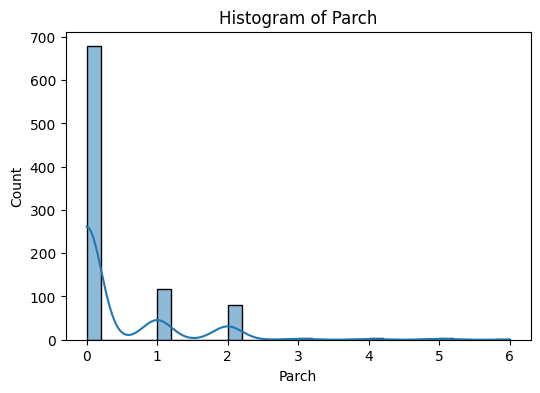

Age      0.510245
Fare     3.112335
SibSp    3.695352
Parch    2.749117
dtype: float64


In [ ]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()
print(df[["Age", "Fare", "SibSp", "Parch"]].skew())



0.33535884393040705


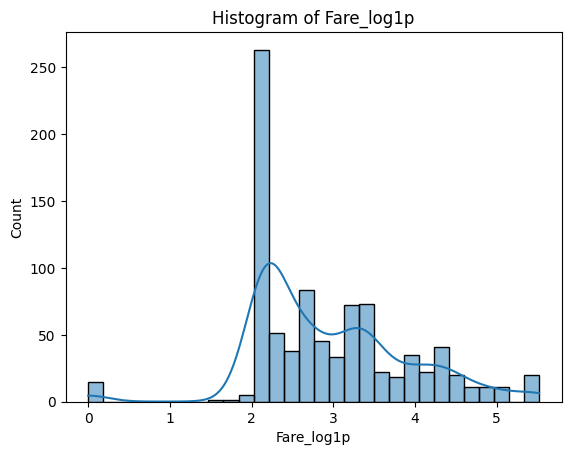

In [ ]:
df["Fare_log1p"] = np.log1p(df["Fare"])
sns.histplot(df["Fare_log1p"], bins=30, kde=True)
plt.title(f"Histogram of Fare_log1p")
print(df["Fare_log1p"].skew())
#After displaying the histograms of the data for all the numerical columns in the dataset, the skewness values ​​are computed. The Fare column was seen to have the most skewness at 4.787317. Hence, the Log transformation using the np.log1p() function was applied to the Fare column to decrease the skewness. Finally, the distribution was displayed before and after the transformation. After applying the transformation to the Fare column, the skewness value was seen to decrease significantly to 0.3949280095189306. Thus, the distribution was seen to be more balanced and less skewed compared to the original form before the transformation.

In [ ]:


df["Age_group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 60, 120],
    labels=["Child", "Teen", "Adult", "Old"],
    right=False
)

df["Age_group"].value_counts()
#I used the function `pd.cut()` to divide the 'Age' column into four groups. This function is used to convert numerical data into categorical data that is easier to analyze. I used simple boundaries such as 'Child,' 'Teen,' 'Adult,' and 'Old,' so that the data is shifted from its original value to its respective category based on its age group. This is similar to data preprocessing techniques used to prepare data for modeling or statistical purposes.

,count
Age_group,
Adult,752
Child,68
Teen,45
Old,26


In [ ]:
corr = df.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df.drop(columns=to_drop, inplace=True, errors='ignore')
print("Dropped:", to_drop)
#I computed the correlation matrix for all the numerical columns in the data. I then took the absolute value of the correlation to deal with very high correlations, regardless of their sign. I then kept only the upper triangle of the matrix to avoid duplicate pairs (A,B) and (B,A). I then looked for any pair with very high correlations (|r| > 0.95) and created a list of redundant columns to delete, since they were conveying almost the same information. I then deleted one column from each pair with very high correlations directly from the data frame, which reduced redundancy and multicollinearity, making the feature set cleaner and more efficient.

Dropped: ['Pclass_ord', 'Age_std', 'Fare_std']


In [ ]:
df.to_excel("Data (Titanic) after engneering(3).xlsx", index=False)